In [1]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix

In [36]:
DATASET_PATH = "data"
BATCH_SIZE = 64
IMG_SIZE = 192
EPOCHS = 8

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Device: cuda
NVIDIA GeForce RTX 5060


In [37]:
# transform = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(10),
#     transforms.ToTensor(),

#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
# ])

transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [38]:
dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=transform
)

print("Clases:", dataset.classes)
print("Total imágenes:", len(dataset))

Clases: ['others', 'safe_driving', 'talking_phone', 'texting_phone', 'turning']
Total imágenes: 7276


In [39]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [40]:
model = models.resnet18(weights="DEFAULT")

num_features = model.fc.in_features

model.fc = torch.nn.Linear(
    num_features,
    len(dataset.classes)
)

model = model.to(device)

In [41]:
# criterion = torch.nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(
#     model.parameters(),
#     lr=0.001
# )

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [42]:
loss_history = []

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {avg_loss:.4f}"
    )

Epoch 1/8 | Loss: 0.6129
Epoch 2/8 | Loss: 0.1857
Epoch 3/8 | Loss: 0.1364
Epoch 4/8 | Loss: 0.1002
Epoch 5/8 | Loss: 0.0817
Epoch 6/8 | Loss: 0.0609
Epoch 7/8 | Loss: 0.0526
Epoch 8/8 | Loss: 0.0456


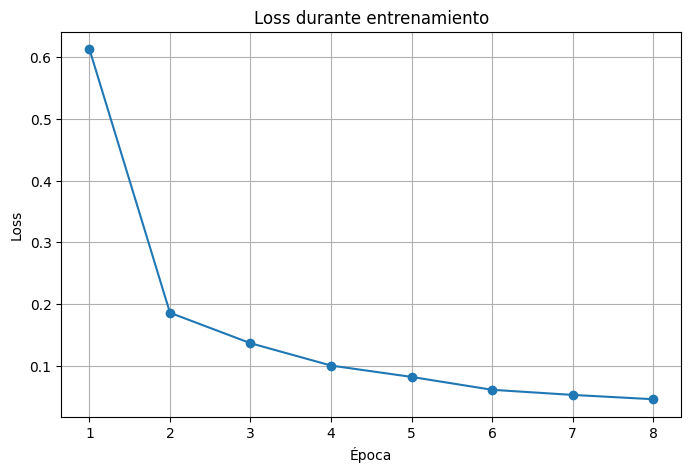

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, EPOCHS + 1),
    loss_history,
    marker='o'
)

plt.title("Loss durante entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

In [44]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

In [45]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=dataset.classes
    )
)

               precision    recall  f1-score   support

       others       0.94      0.89      0.92       243
 safe_driving       0.91      0.97      0.94       324
talking_phone       0.99      0.98      0.99       313
texting_phone       0.99      0.98      0.99       303
      turning       0.96      0.96      0.96       273

     accuracy                           0.96      1456
    macro avg       0.96      0.96      0.96      1456
 weighted avg       0.96      0.96      0.96      1456



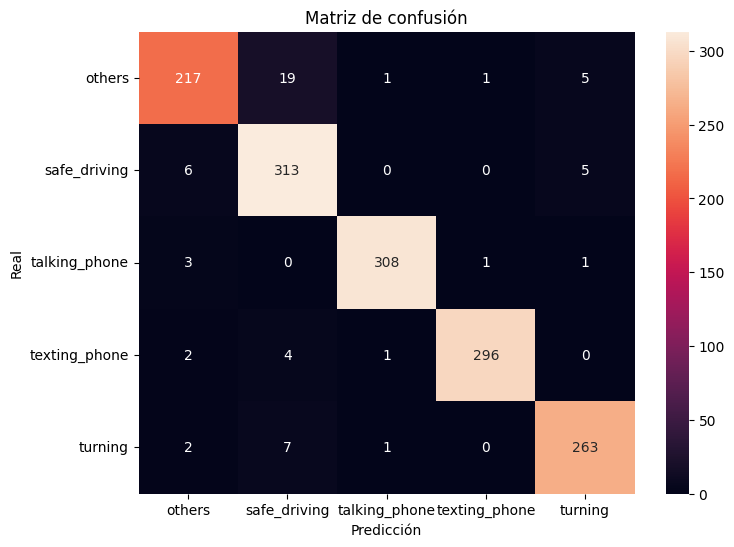

In [46]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

In [47]:
model.eval()

misclassified_images = []
misclassified_true = []
misclassified_pred = []

with torch.no_grad():

    for images, labels in val_loader:

        images_gpu = images.to(device)

        outputs = model(images_gpu)

        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):

            if preds[i].cpu() != labels[i]:

                misclassified_images.append(images[i])
                misclassified_true.append(labels[i].item())
                misclassified_pred.append(
                    preds[i].cpu().item()
                )

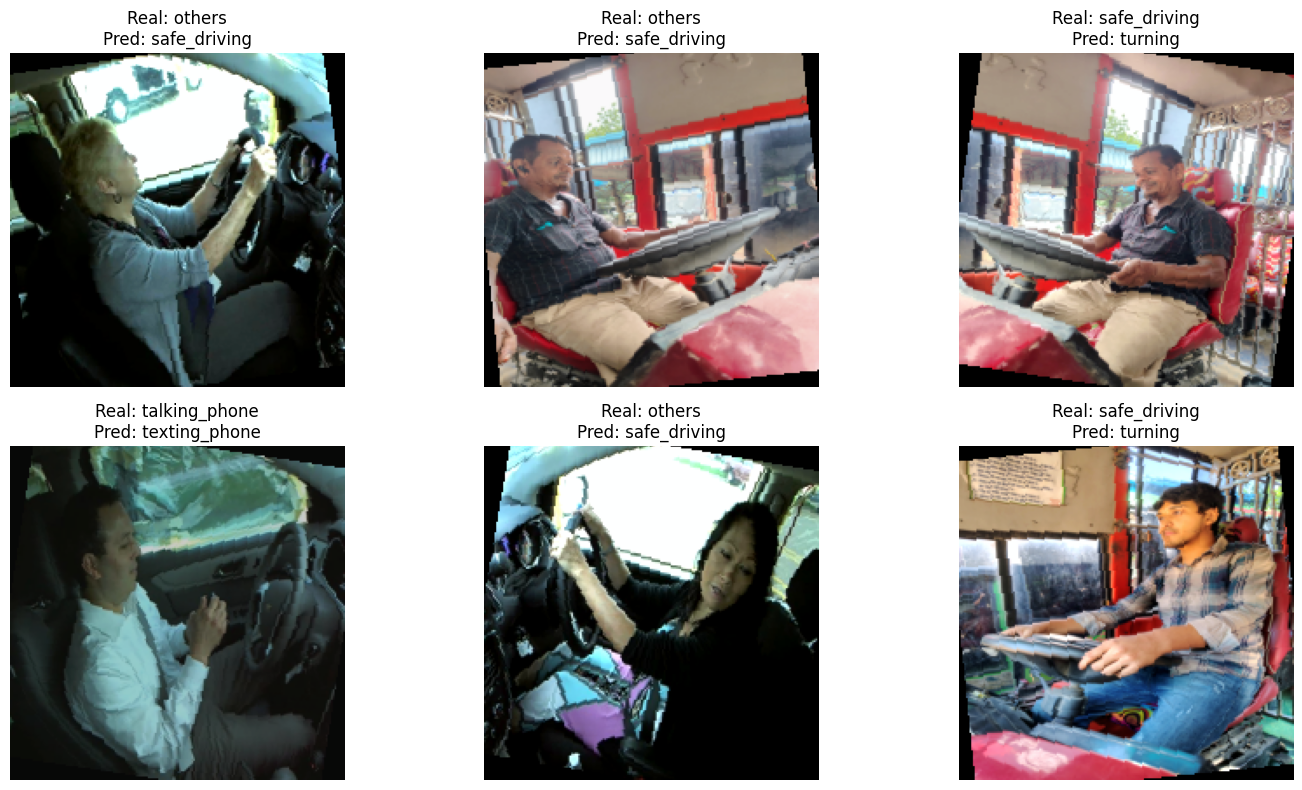

In [48]:
num_examples = 6

plt.figure(figsize=(15,8))

for i in range(num_examples):

    img = misclassified_images[i]
    img = img.permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img * std + mean
    img = np.clip(img, 0, 1)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)

    true_label = dataset.classes[
        misclassified_true[i]
    ]

    pred_label = dataset.classes[
        misclassified_pred[i]
    ]

    plt.title(
        f"Real: {true_label}\nPred: {pred_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [49]:
torch.save({
    "model_state_dict": model.state_dict(),
    "classes": dataset.classes
}, "driver_behavior_model.pth")